In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [35]:
# Load dataset
df = pd.read_csv("train.csv")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [38]:
print("shape of Data",df.shape)

shape of Data (9800, 18)


In [39]:
print("Coumns Names:",df.columns)

Coumns Names: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

## #Data Cleaning

In [41]:
print("Missing Values:\n",df.isnull().sum())

Missing Values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [42]:
df["Postal Code"] = df["Postal Code"].fillna(df["Postal Code"].median())
print(df.isnull().sum().sum())

0


In [43]:
print("Duplicates:",df.duplicated().sum())

Duplicates: 0


In [44]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [45]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed", dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="mixed", dayfirst=True)

In [46]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [47]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Year"] = df["Order Date"].dt.year
df["Month_Number"] = df["Order Date"].dt.month
df["Month"] = df["Order Date"].dt.to_period("M")



## #EDA-(Exploratory Data Analysis) 

#### Monthly sales trend

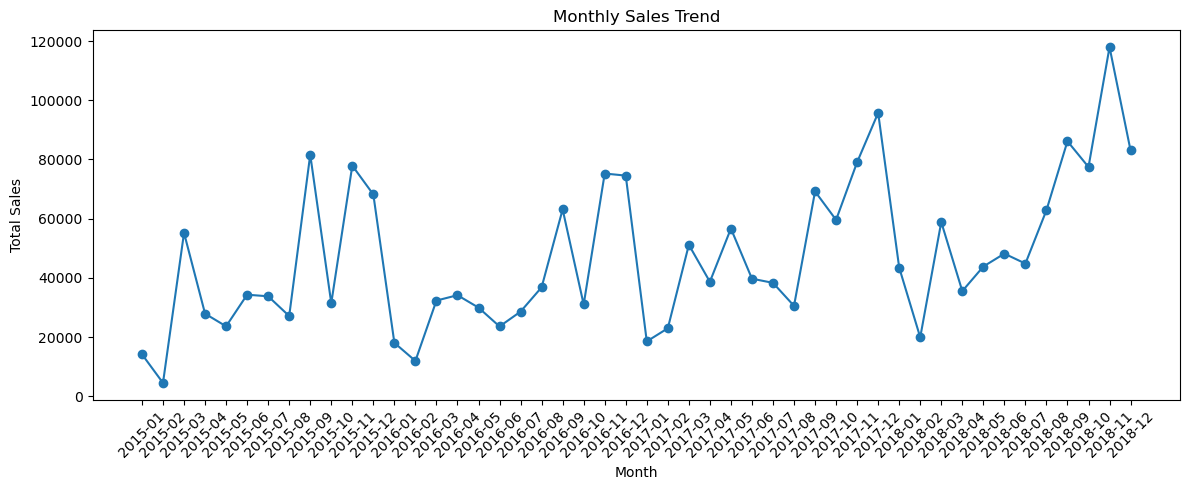

In [48]:
monthly_sales = df.groupby("Month")["Sales"].sum()
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Sales by category

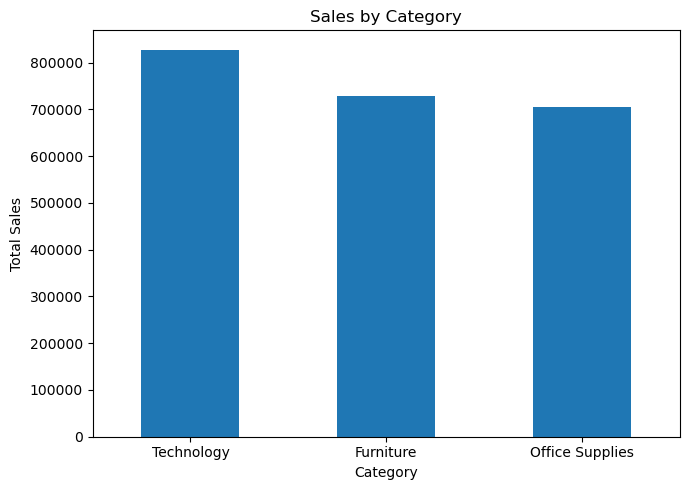

In [49]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Sales by region


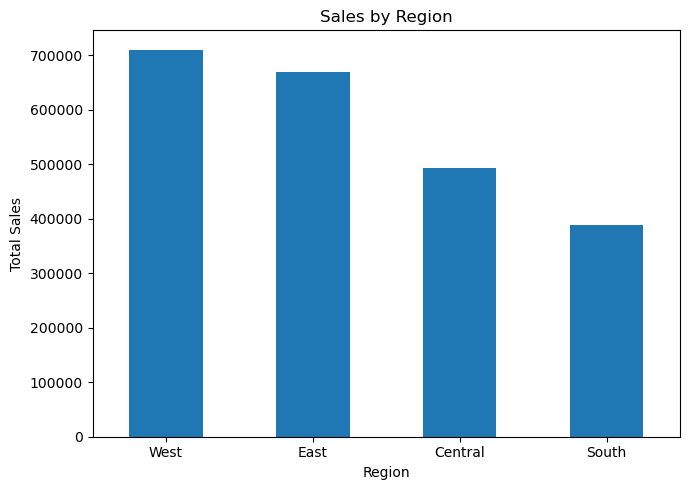

In [50]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Top 10 products by sales

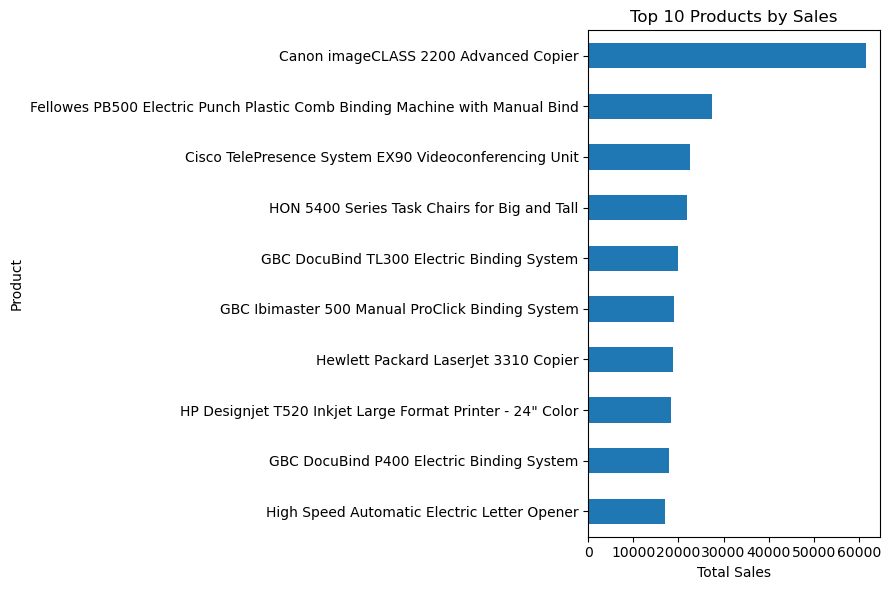

In [51]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)
plt.figure(figsize=(9, 6))
top_products.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

#### Sales by customer segment

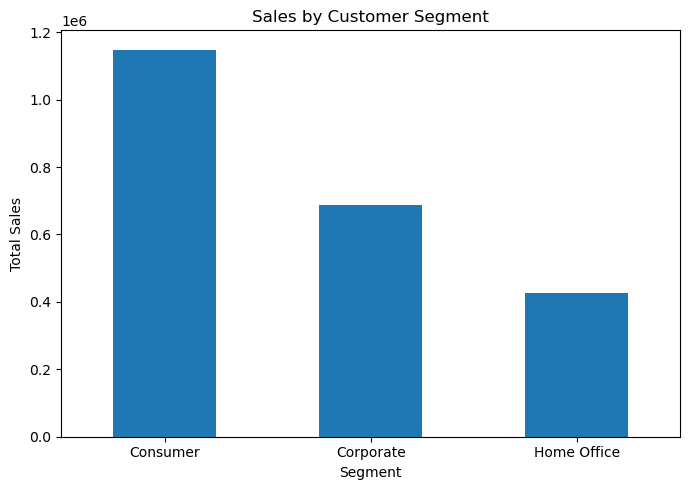

In [52]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
segment_sales.plot(kind="bar")
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### Correlation heatmap for available numeric analysis variables

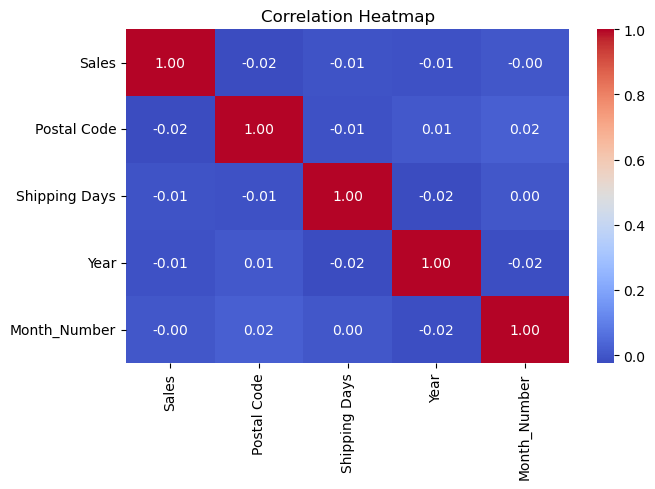

In [53]:
corr_cols = ["Sales", "Postal Code", "Shipping Days", "Year", "Month_Number"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## #Statistical Summary

In [54]:
print("Mean:", df['Sales'].mean())
print("Median:", df['Sales'].median())
print("Standard Deviation:", df['Sales'].std())

Mean: 230.76905945918367
Median: 54.489999999999995
Standard Deviation: 626.6518748388047


In [55]:
df['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

### Insights:
#### 1. Most sales are small: The average sale is about 230.77, but the middle sale is only 54.49. This means most sales are on the lower side.
#### 2. 75% of sales are below 210.61: This shows that most customers make purchases of less than 210.
#### 3. A few sales are very large: Sales range from 0.44 to 22,638.48. A few very high sales increase the average and make the data spread out.

## #Monthly Sales Forecasting Model

#### A Linear Regression model is used to predict sales. Since the data is based on time, the first 80% of the months are used to train the model, and the last 20% are used to test it. The model also uses the month to understand seasonal sales patterns.

In [58]:
monthly = df.groupby("Month", as_index=False)["Sales"].sum()
monthly["time_index"] = np.arange(len(monthly))
monthly["month_num"] = monthly["Month"].dt.month
month_dummies = pd.get_dummies(monthly["month_num"], prefix="month", dtype=int)

In [59]:
X = pd.concat([monthly[["time_index"]], month_dummies], axis=1)
y = monthly["Sales"]


In [60]:
split_index = int(len(monthly) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


In [61]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
prediction = model.predict(X_test)

In [63]:
print("Training months:", len(X_train))
print("Testing months:", len(X_test))

Training months: 38
Testing months: 10


In [64]:
r2 = r2_score(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
mae = mean_absolute_error(y_test, prediction)

print(f"R-Squared (R²): {r2:.3f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")

R-Squared (R²): 0.637
RMSE: 14,478.82
MAE: 10,520.28


####  Actual vs predicted monthly sales

In [65]:
comparison_df = pd.DataFrame({
    "Month": monthly["Month"].iloc[split_index:].astype(str).values,
    "Actual Sales": y_test.values,
    "Predicted Sales": prediction
})


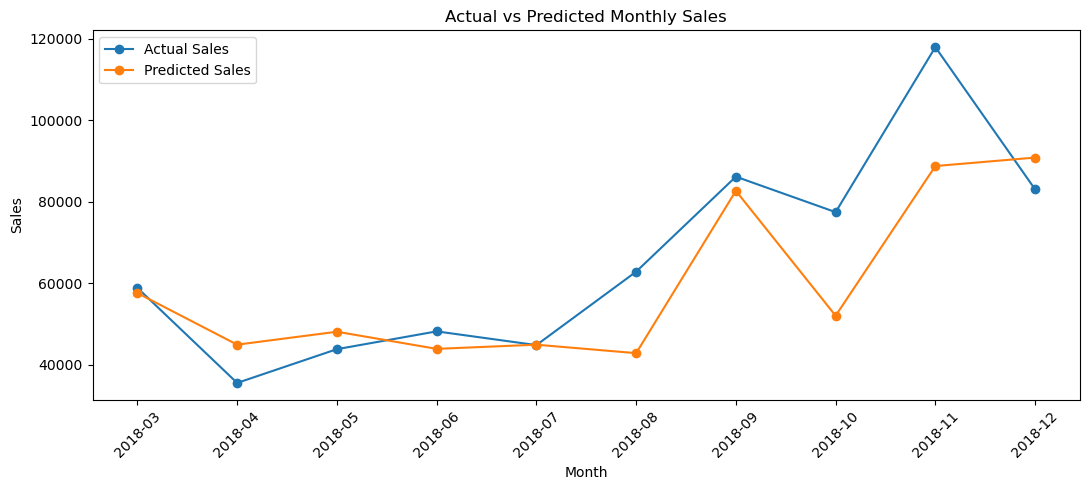

In [66]:
plt.figure(figsize=(11, 5))
plt.plot(comparison_df["Month"], comparison_df["Actual Sales"], marker="o", label="Actual Sales")
plt.plot(comparison_df["Month"], comparison_df["Predicted Sales"], marker="o", label="Predicted Sales")
plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Model interpretation
#### The model has an R² score of about 0.637. This means the model can explain a good part of the changes in monthly sales, but it cannot predict every change accurately. The RMSE and MAE also show that there are still some prediction errors. So, this model can be used as a basicstarting point for forecasting, but it may need improvement for better results.

Sales forecast for the next 6 months:
     Month  Forecast Sales
0  2019-01    37764.566750
1  2019-02    29034.438200
2  2019-03    63266.716020
3  2019-04    50610.354720
4  2019-05    53783.571720
5  2019-06    49578.923087


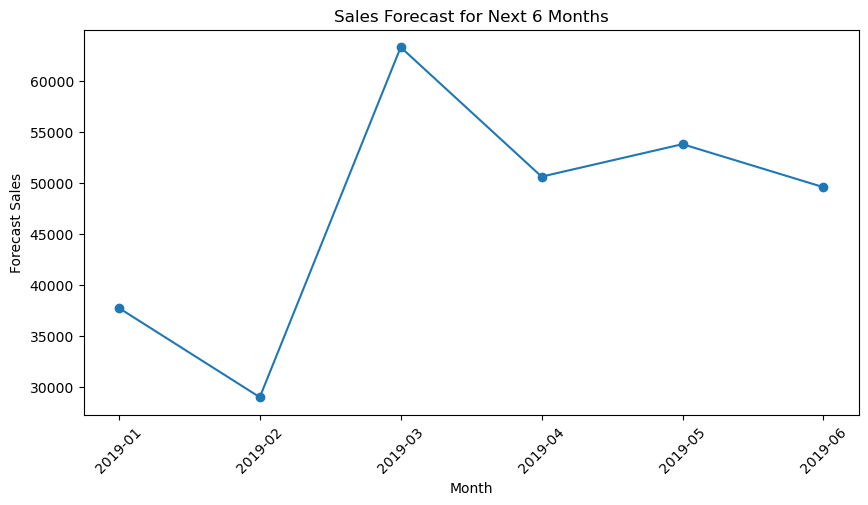

In [69]:
future = pd.DataFrame()
future["Month"] = pd.period_range(start=monthly["Month"].max() + 1,periods=6, freq="M")
future["time_index"] = range(len(monthly), len(monthly) + 6)
future["month_num"] = future["Month"].dt.month
month_data = pd.get_dummies(future["month_num"],prefix="month",dtype=int)

future_X = pd.concat(
    [future[["time_index"]], month_data],
    axis=1
)
future_X = future_X.reindex(columns=X.columns,fill_value=0)
future["Forecast Sales"] = model.predict(future_X)
print("Sales forecast for the next 6 months:")
print(future[["Month", "Forecast Sales"]])

# graph
plt.figure(figsize=(10, 5))
plt.plot(future["Month"].astype(str),future["Forecast Sales"],marker="o")
plt.title("Sales Forecast for Next 6 Months")
plt.xlabel("Month")
plt.ylabel("Forecast Sales")
plt.xticks(rotation=45)
plt.show()

## #Business Recommendations
#### 1. Focus on Technology products: Technology has the highest sales, so the business should keep enough stock and promote these products.
#### 2. Focus on the West region: The West has the highest sales. The business should continue its marketing and sales efforts in this region.
#### 3. Prepare for busy months: Sales are usually higher toward the end of the year, especially in November and December. The business should prepare stock and marketing early.
#### 4. Improve the South region: The South has the lowest sales. The business can offer special deals and study customer needs to increase sales.
#### 5. Use the forecast as a starting point: The current model gives a basic sales forecast. A better model and more data could help make the predictions more accurate.